<a href="https://colab.research.google.com/github/NishigandhaChoudhury/Neural-Network-and-Deep-Learning-Lab-Experiments/blob/main/NNDLLAB17(15).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

actual exp 15

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import time
import os

In [ ]:
from google.colab import files

print("Upload your kaggle.json file:")
files.upload()

import os
os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download PlantVillage (subset — only 4 disease classes)
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip
print("Dataset downloaded!")

Upload your kaggle.json file:


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:17<00:00, 40.3MB/s]

Dataset downloaded!


In [ ]:
# SET THIS MANUALLY:
# True  = use CIFAR-10 (no Kaggle needed) ← use this if you skipped Kaggle
# False = use real PlantVillage dataset
USE_SYNTHETIC = True

IMG_SIZE  = (96, 96)
BATCH     = 32
NUM_CLASS = 4

if not USE_SYNTHETIC:
    # Real PlantVillage path
    BASE = "PlantVillage"
    DISEASE_NAMES = sorted(os.listdir(BASE))[:4]
    print("Using classes:", DISEASE_NAMES)

    train_aug = ImageDataGenerator(
        rescale=1./255,
        rotation_range=30,
        zoom_range=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        brightness_range=[0.8, 1.2],
        width_shift_range=0.1,
        height_shift_range=0.1,
        validation_split=0.2
    )
    train_data = train_aug.flow_from_directory(
        BASE, target_size=IMG_SIZE, batch_size=BATCH,
        classes=DISEASE_NAMES, class_mode='categorical',
        subset='training'
    )
    val_data = train_aug.flow_from_directory(
        BASE, target_size=IMG_SIZE, batch_size=BATCH,
        classes=DISEASE_NAMES, class_mode='categorical',
        subset='validation'
    )

else:
    # Synthetic CIFAR-10 path
    DISEASE_NAMES = ["Healthy", "Rust", "Blight", "Powdery Mold"]
    selected      = [2, 3, 4, 5]

    # Load CIFAR-10 now (in case Cell 2 synthetic block wasn't run)
    (x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = \
        tf.keras.datasets.cifar10.load_data()

    def filter_classes(x, y, classes):
        mask  = np.isin(y.flatten(), classes)
        xf    = x[mask]
        yf    = y[mask].flatten()
        remap = {c: i for i, c in enumerate(classes)}
        yr    = np.array([remap[v] for v in yf])
        xf_r  = tf.image.resize(xf, IMG_SIZE).numpy()
        return xf_r / 255.0, yr

    x_tr, y_tr = filter_classes(x_train_raw, y_train_raw, selected)
    x_te, y_te = filter_classes(x_test_raw,  y_test_raw,  selected)

    y_tr_cat = tf.keras.utils.to_categorical(y_tr, NUM_CLASS)
    y_te_cat = tf.keras.utils.to_categorical(y_te, NUM_CLASS)

    print(f"Train samples : {len(x_tr)}")
    print(f"Test  samples : {len(x_te)}")
    print(f"Classes       : {DISEASE_NAMES}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Train samples : 20000
Test  samples : 4000
Classes       : ['Healthy', 'Rust', 'Blight', 'Powdery Mold']


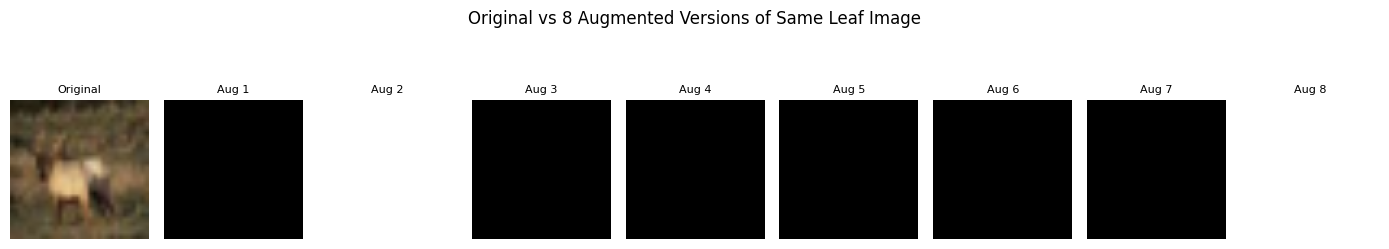

In [ ]:
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomBrightness(0.2),
])

sample = x_tr[:1]

plt.figure(figsize=(14, 3))
plt.subplot(1, 9, 1)
plt.imshow(sample[0]); plt.title("Original", fontsize=8); plt.axis('off')

for i in range(8):
    aug_img = aug(sample, training=True)[0].numpy()
    plt.subplot(1, 9, i+2)
    plt.imshow(np.clip(aug_img, 0, 1))
    plt.title(f"Aug {i+1}", fontsize=8); plt.axis('off')

plt.suptitle("Original vs 8 Augmented Versions of Same Leaf Image")
plt.tight_layout(); plt.show()

In [ ]:
def build_scratch(num_classes=4):
    model = models.Sequential([
        layers.RandomFlip("horizontal_and_vertical",
                          input_shape=(*IMG_SIZE, 3)),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

scratch_model = build_scratch()
scratch_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 96, 96, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 96, 96, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
def build_transfer(num_classes=4):
    base = MobileNetV2(weights='imagenet',
                       include_top=False,
                       input_shape=(*IMG_SIZE, 3))
    base.trainable = False   # freeze pretrained weights

    model = models.Sequential([
        layers.RandomFlip("horizontal_and_vertical",
                          input_shape=(*IMG_SIZE, 3)),
        layers.RandomRotation(0.2),
        layers.RandomZoom(0.2),
        base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

transfer_model = build_transfer()
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 96, 96, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_2 (RandomZoom)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
EPOCHS = 5

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True
)

# --- Train Scratch ---
print("Training FROM SCRATCH...")
t0 = time.time()
scratch_history = scratch_model.fit(
    x_tr, y_tr_cat,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(x_te, y_te_cat),
    callbacks=[early_stop],
    verbose=1
)
scratch_time = time.time() - t0
print(f"\nScratch training time : {scratch_time:.1f}s")

# --- Train Transfer ---
print("\nTraining TRANSFER LEARNING (MobileNetV2)...")
t0 = time.time()
transfer_history = transfer_model.fit(
    x_tr, y_tr_cat,
    epochs=EPOCHS,
    batch_size=BATCH,
    validation_data=(x_te, y_te_cat),
    callbacks=[early_stop],
    verbose=1
)
transfer_time = time.time() - t0
print(f"\nTransfer training time : {transfer_time:.1f}s")

Training FROM SCRATCH...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 667s 1s/step - accuracy: 0.3898 - loss: 1.2829 - val_accuracy: 0.4218 - val_loss: 1.2246
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 670s 1s/step - accuracy: 0.4358 - loss: 1.2109 - val_accuracy: 0.4067 - val_loss: 1.3108
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 681s 1s/step - accuracy: 0.4581 - loss: 1.1814 - val_accuracy: 0.4730 - val_loss: 1.1606
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 674s 1s/step - accuracy: 0.4734 - loss: 1.1690 - val_accuracy: 0.4530 - val_loss: 1.1795
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 676s 1s/step - accuracy: 0.4818 - loss: 1.1534 - val_accuracy: 0.4895 - val_loss: 1.1319

Scratch training time : 3372.6s

Training TRANSFER LEARNING (MobileNetV2)...
Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 220s 335ms/step - accuracy: 0.5328 - loss: 1.0907 - val_accuracy: 0.6805 - val_loss: 0.7970
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 207s 331ms/step - accuracy: 0.5764 - loss: 1.0026 - val_accuracy: 0.7032 - val_loss: 0.

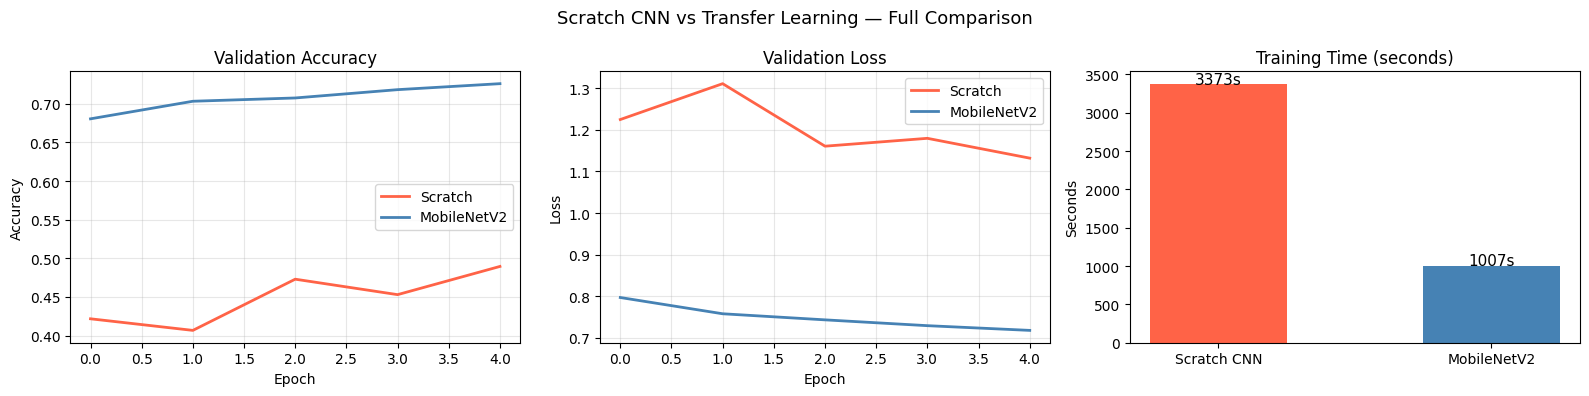

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(scratch_history.history['val_accuracy'],
             color='tomato',    linewidth=2, label='Scratch')
axes[0].plot(transfer_history.history['val_accuracy'],
             color='steelblue', linewidth=2, label='MobileNetV2')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(scratch_history.history['val_loss'],
             color='tomato',    linewidth=2, label='Scratch')
axes[1].plot(transfer_history.history['val_loss'],
             color='steelblue', linewidth=2, label='MobileNetV2')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].bar(['Scratch CNN', 'MobileNetV2'],
            [scratch_time, transfer_time],
            color=['tomato', 'steelblue'], width=0.5)
axes[2].set_title('Training Time (seconds)')
axes[2].set_ylabel('Seconds')
for i, v in enumerate([scratch_time, transfer_time]):
    axes[2].text(i, v + 1, f'{v:.0f}s', ha='center', fontsize=11)

plt.suptitle('Scratch CNN vs Transfer Learning — Full Comparison',
             fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
_, s_acc = scratch_model.evaluate(x_te,  y_te_cat, verbose=0)
_, t_acc = transfer_model.evaluate(x_te, y_te_cat, verbose=0)

print("=" * 50)
print(f"  Scratch   CNN  → Accuracy : {s_acc:.2%} | "
      f"Time : {scratch_time:.0f}s")
print(f"  MobileNetV2    → Accuracy : {t_acc:.2%} | "
      f"Time : {transfer_time:.0f}s")
print(f"  Accuracy gain  → +{(t_acc - s_acc):.2%}")
print(f"  Time saved     → "
      f"{abs(scratch_time - transfer_time):.0f}s "
      f"({'faster' if transfer_time < scratch_time else 'slower'})")
print("=" * 50)

  Scratch   CNN  → Accuracy : 48.95% | Time : 3373s
  MobileNetV2    → Accuracy : 72.60% | Time : 1007s
  Accuracy gain  → +23.65%
  Time saved     → 2366s (faster)


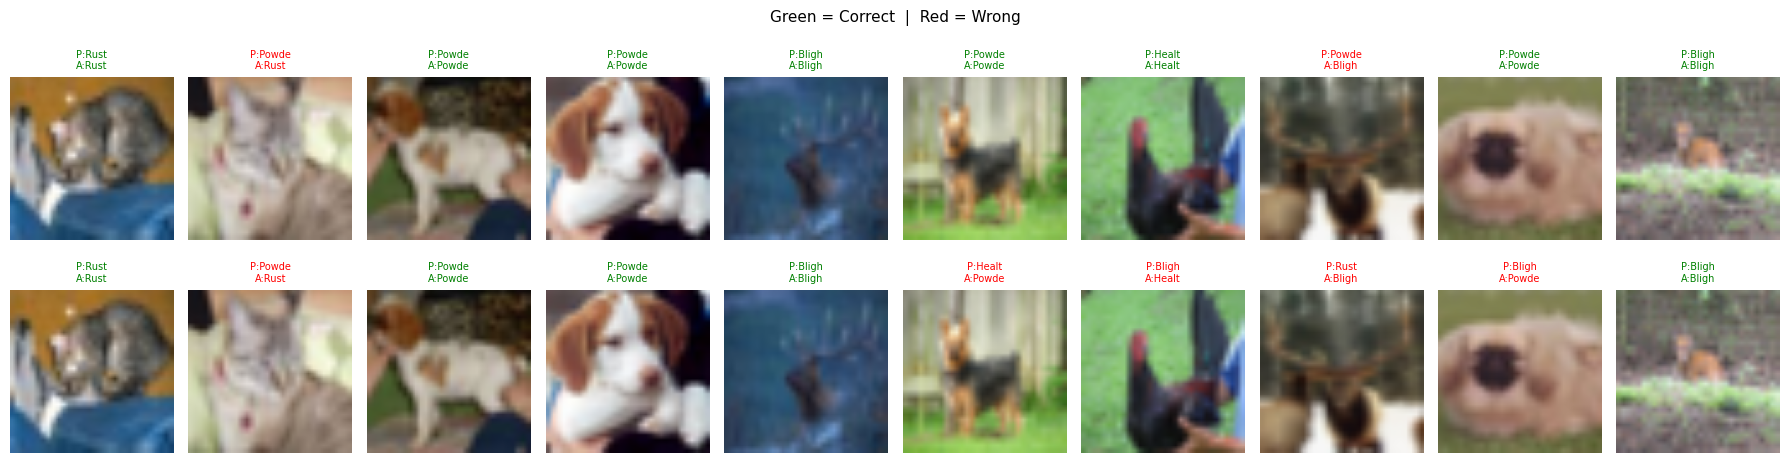

In [ ]:
sample_imgs   = x_te[:10]
sample_labels = np.argmax(y_te_cat[:10], axis=1)

t_preds = np.argmax(
    transfer_model.predict(sample_imgs, verbose=0), axis=1)
s_preds = np.argmax(
    scratch_model.predict(sample_imgs,  verbose=0), axis=1)

fig, axes = plt.subplots(2, 10, figsize=(18, 5))
for i in range(10):
    for row, preds, title in [
        (0, t_preds, "Transfer"),
        (1, s_preds, "Scratch")
    ]:
        axes[row, i].imshow(np.clip(sample_imgs[i], 0, 1))
        ok    = preds[i] == sample_labels[i]
        color = 'green' if ok else 'red'
        axes[row, i].set_title(
            f"P:{DISEASE_NAMES[preds[i]][:5]}\n"
            f"A:{DISEASE_NAMES[sample_labels[i]][:5]}",
            fontsize=7, color=color
        )
        axes[row, i].axis('off')

axes[0, 0].set_ylabel("MobileNetV2\nTransfer", fontsize=9)
axes[1, 0].set_ylabel("Scratch\nCNN",          fontsize=9)
plt.suptitle("Green = Correct  |  Red = Wrong", fontsize=11)
plt.tight_layout(); plt.show()